# EV Charging Optimization - Deterministic MPC

This notebook demonstrates how **Model Predictive Control (MPC)** can optimize electric vehicle (EV) charging schedules to minimize electricity costs while meeting charging requirements.

## Overview

**What this notebook does:**
- Loads the same plant data from `01_benchmark.ipynb` with EV charging patterns
- Calculates baseline costs for uncontrolled EV charging
- Applies deterministic MPC optimization to schedule EV charging optimally
- Compares optimized vs baseline results to quantify cost savings

**Key optimization objectives:**
- Minimize total electricity costs (energy + peak charges + spot prices)
- Shift charging to low-price periods
- Reduce peak power demand to lower capacity charges
- Utilize PV production when available
- Meet all EV charging requirements (daily energy needs, power limits)

**Expected outcomes:**
- Significant cost reduction through intelligent load shifting
- Lower peak power demand
- Better alignment with renewable energy production
- Detailed visualizations comparing baseline vs optimized strategies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Add src to path
sys.path.append(str(Path("..") / "src"))

from optimization import deterministic_mpc_ev
from billing import load_billing_config, calculate_monthly_bills

print("Libraries imported successfully")

Libraries imported successfully


## Load Data

This section loads the plant data from `plant1.csv`, which contains the same dataset used in `01_benchmark.ipynb`.

**What you'll see:**
- **Data summary** showing:
  - Total number of records (15-minute intervals for one year)
  - Available columns (timestamp, grid consumption, prices, PV production, EV data, etc.)
  - Date range of the dataset
  - Statistical summary of key variables:
    - Grid consumption (kWh)
    - PV production (kWh)
    - Grid injection (kWh)
    - EV charging (kWh)
    - Inflexible load (kWh)
    - Electricity prices (€/MWh)

This data provides the foundation for both baseline cost calculation and optimization.

In [2]:
# Load plant data (same as 01_benchmark.ipynb)
df = pd.read_csv("../data/plant1.csv", parse_dates=["timestamp"])

# Normalize column names (handles accidental leading/trailing spaces)
df.columns = df.columns.str.strip()

print(f"Data loaded: {len(df)} rows")
print(f"Columns: {list(df.columns)}")
print(f"\nDate range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"\nData summary:")
print(df[['grid_consumption', 'pv_production', 'grid_injection', 'ev', 'inflex_load', 'price']].describe())

Data loaded: 35040 rows
Columns: ['timestamp', 'grid_consumption', 'price', 'pv_production', 'grid_injection', 'total_consumption', 'ev', 'inflex_load', 'grid_consumption_excl_ev', 'thermal_load', 'outdoor_temperature']

Date range: 2025-01-01 00:00:00+01:00 to 2025-12-31 23:45:00+01:00

Data summary:
       grid_consumption  pv_production  grid_injection            ev  \
count      35040.000000   35040.000000    35040.000000  35040.000000   
mean         330.554338      51.857346        0.004944      9.856753   
std          155.762869      87.539674        0.237750     20.675190   
min            0.000000       0.000000        0.000000      0.000000   
25%          184.625000       0.000000        0.000000      0.000000   
50%          372.750000       0.000000        0.000000      0.000000   
75%          456.750000      75.425000        0.000000      8.028882   
max          705.250000     424.100000       19.250000    148.400000   

        inflex_load         price  
count  35040

## Calculate Non-Optimized Costs (Baseline)

This section calculates the electricity costs for the **actual, uncontrolled EV charging pattern** observed in the data. This serves as the baseline for comparison.

**What you'll see:**
- **Monthly billing breakdown** for the baseline scenario showing:
  - Energy costs (volume × energy rate)
  - Spot price costs (variable electricity prices)
  - Peak-based costs (monthly peak power charges)
  - Injection revenue (from excess PV production)
  - Net total costs

- **Annual totals** summarizing:
  - Total energy cost
  - Total spot cost
  - Total peak cost
  - Total injection revenue
  - Net total annual cost

This baseline represents the "business as usual" scenario where EV charging happens without optimization, often during peak demand periods when electricity is most expensive.

In [3]:
# Calculate baseline costs using actual EV charging pattern
# Conservative access power policy for baseline:
# access_power_conservative[m] = max(observed monthly peak up to m-1) + 20 kW

config_path = "../config/billing.yaml"
config = load_billing_config(config_path)

df_baseline = df.copy()

# Month labels must match billing.py. CSV has mixed +01:00 (CET) and +02:00 (CEST).
# A single pd.to_datetime() on the column infers one timezone and turns CEST rows into NaT,
# which drops Apr–Sep from groupby and shows 0 kW peaks there.
ts_raw = df_baseline["timestamp"]
if ts_raw.dtype == "object" or isinstance(
    ts_raw.iloc[0] if len(ts_raw) else None, str
):
    ts_naive = ts_raw.astype(str).str.replace(r"[+-]\d{2}:\d{2}$", "", regex=True)
    ts_naive = pd.to_datetime(ts_naive, errors="coerce")
else:
    ts_naive = pd.to_datetime(ts_raw, errors="coerce")
    if ts_naive.dt.tz is not None:
        ts_naive = ts_naive.dt.tz_localize(None)

naive_timestamps = pd.to_datetime(
    ts_naive.dt.strftime("%Y-%m-%d %H:%M:%S"),
    format="%Y-%m-%d %H:%M:%S",
)
df_baseline["month"] = naive_timestamps.dt.to_period("M")

# Conservative AP settings (seed aligned with notebook 09 2024 spillover)
MARGIN_KW = 20.0
BASELINE_2024_PEAK_GRID_KW = 2663.5

months_2025 = pd.period_range("2025-01", "2025-12", freq="M")
monthly_peak_baseline_kw = (
    (df_baseline.groupby("month")["grid_consumption"].max() * 4.0)
    .reindex(months_2025)
    .fillna(0.0)
)

cummax_M_minus_1_kw = monthly_peak_baseline_kw.cummax().shift(1)
cummax_M_minus_1_kw.loc[months_2025.min()] = BASELINE_2024_PEAK_GRID_KW
cummax_M_minus_1_kw = cummax_M_minus_1_kw.fillna(BASELINE_2024_PEAK_GRID_KW)

access_power_conservative = cummax_M_minus_1_kw + MARGIN_KW

# Map monthly conservative AP to each timestep for billing input
df_baseline["baseline_access_power_conservative"] = (
    df_baseline["month"].map(access_power_conservative.to_dict()).astype(float)
)
df["baseline_access_power_conservative"] = df_baseline["baseline_access_power_conservative"]

# Calculate monthly bills for baseline using conservative AP
baseline_bills = calculate_monthly_bills(
    df_baseline,
    config,
    access_power_col="baseline_access_power_conservative",
)

# Diagnostics: show no-foresight AP construction by month
ap_diagnostics = pd.DataFrame(
    {
        "baseline_monthly_peak_kw": monthly_peak_baseline_kw.values,
        "cummax_M_minus_1_kw": cummax_M_minus_1_kw.values,
        "access_power_conservative_kw": access_power_conservative.values,
    },
    index=months_2025,
)
print("Conservative baseline access power (previous max + 20 kW):")
display(ap_diagnostics.round(1))

# Calculate injection revenue separately
from billing import calculate_monthly_injection_bills
baseline_injection = calculate_monthly_injection_bills(df_baseline, config)
baseline_injection_revenue = baseline_injection['injection_net_revenue_eur'].sum()
baseline_net_total = baseline_bills['total_cost_eur'].sum() - baseline_injection_revenue

print("="*80)
print("BASELINE (Non-Optimized) COSTS")
print("="*80)
print(f"\nTotal Energy Cost:     {baseline_bills['energy_cost_eur'].sum():>15,.2f} EUR")
print(f"Total Spot Cost:       {baseline_bills['spot_cost_eur'].sum():>15,.2f} EUR")
print(f"Total Peak Cost:       {baseline_bills['peak_based_cost_eur'].sum():>15,.2f} EUR")
print(f"Injection Revenue:     {baseline_injection_revenue:>15,.2f} EUR")
print(f"{'-'*50}")
print(f"NET TOTAL COST:        {baseline_net_total:>15,.2f} EUR")
print("="*80)

Conservative baseline access power (previous max + 20 kW):


,baseline_monthly_peak_kw,cummax_M_minus_1_kw,access_power_conservative_kw
2025-01,2684.5,2663.5,2683.5
2025-02,2726.5,2684.5,2704.5
2025-03,2527.0,2726.5,2746.5
2025-04,2506.0,2726.5,2746.5
2025-05,2485.0,2726.5,2746.5
2025-06,2411.5,2726.5,2746.5
2025-07,2362.5,2726.5,2746.5
2025-08,2240.0,2726.5,2746.5
2025-09,2604.0,2726.5,2746.5
2025-10,2821.0,2726.5,2746.5


BASELINE (Non-Optimized) COSTS

Total Energy Cost:          375,450.30 EUR
Total Spot Cost:          1,075,304.89 EUR
Total Peak Cost:            231,006.05 EUR
Injection Revenue:               10.02 EUR
--------------------------------------------------
NET TOTAL COST:           1,681,751.22 EUR


## Run Optimization

This section runs the **deterministic MPC optimization** to find the optimal EV charging schedule that minimizes total costs.

**What the optimization does:**
- **Optimization model setup:**
  - Creates a mathematical optimization model with constraints
  - Defines objective function to minimize total costs
  - Sets up constraints for:
    - EV power limits (maximum charging rate)
    - EV power envelope (available charging windows)
    - Daily energy requirements (must meet EV demand)
    - Power balance (grid consumption = inflexible load + EV charging - PV production)
    - Monthly peak power tracking
    - Access power rules

- **Optimization process:**
  - Solves the optimization problem for all 35,040 time periods (one year)
  - Determines optimal charging schedule considering:
    - Electricity prices (charge when prices are low)
    - PV production availability (prefer charging during solar generation)
    - Peak power reduction (avoid simultaneous high loads)
    - Daily energy requirements (ensure all EVs are fully charged)

**What you'll see:**
- Progress indicators showing optimization steps
- Model statistics (number of variables, constraints, time periods)
- Optimization results including:
  - Optimized EV charging schedule
  - Optimized grid consumption
  - Optimized monthly peak powers
  - Optimized access power

The optimization typically takes several minutes to solve for a full year of data.

### Optimization Model: Objective Function and Constraints

The optimization model (from `src/optimization.py`) minimizes total cost while meeting all operational constraints:

#### Objective Function
Minimize: **Total Cost = Energy Cost + Spot Cost + Peak-Based Costs - Injection Revenue**

**Energy Cost:**
- Formula: `Σ(grid_consumption[t] × (energy_rate_eur_per_mwh/1000 + grid_losses_percentage × spot_price[t]))`
- Energy rate: ~30.4 €/MWh (fixed costs from config)
- Grid losses: 1.75% of spot price per interval

**Spot Cost:**
- Formula: `Σ(grid_consumption[t] × spot_price_eur_per_kwh[t])`
- Spot price converted from €/MWh to €/kWh

**Peak-Based Costs:**
- Access power cost: `Σ(access_power[m] × 2.9975458)` per month
- Monthly peak cost: `Σ(monthly_peak[m] × 4.2269465)` per month
- Over-usage cost: `Σ(rolling_max_exceedance[m] × 4.4963187)` per month

**Injection Revenue** (negative cost):
- Formula: `-Σ(grid_injection[t] × net_injection_price_eur_per_kwh[t])`
- Net injection price = spot_price - imbalance_cost (4.612 €/MWh)

#### Constraints

**EV Charging Constraints:**
1. **Power Conversion**: `ev_charge_power[t] = ev_charge[t] × 4` (kWh to kW)
2. **Power Envelope**: `ev_charge_power[t] ≤ ev_power_envelope[t]` (limited by actual charging pattern)
3. **Daily Energy**: `Σ(ev_charge[t] for t in day) = daily_ev_energy_demand[day]` (must meet daily demand)

**Power Balance:**
- `grid_consumption[t] - grid_injection[t] = inflex_load[t] + ev_charge[t] - pv_production[t]`
- Net grid power = Total load - PV production

**Grid Power:**
- `grid_power[t] = (grid_consumption[t] - grid_injection[t]) × 4` (kW, positive = consumption)

**Peak Tracking:**
- `monthly_peak[m] ≥ grid_consumption[t] × 4` for all periods t in month m
- Peak is based on grid consumption (offtake), not net power

**Exceedance:**
- `exceedance[t] ≥ monthly_peak[m] - access_power[m]` for all periods t in month m
- Rolling max exceedance: `rolling_max_exceedance[m] ≥ exceedance[k]` for k in [m-11, m]

**Access Power Rules:**
- Access power can be increased at any time (monthly)
- Access power can only be reduced 12 months after an increase (lock-in period)
- Binary variables track increases and enforce lock-in constraints

#### Key Parameters (from `config/billing.yaml`)
- **Energy costs**: Fixed rate ~30.4 €/MWh, grid losses 1.75%
- **Peak costs**: Access power 2.9975 €/kW/month, Monthly peak 4.227 €/kW/month, Over-usage 4.496 €/kW/month
- **Injection**: Imbalance cost 4.612 €/MWh (deducted from spot price)
- **Access power**: Default 2850 kW/month (optimized variable)
Optimize EV charging schedule to minimize total costs.

In [4]:
# Run deterministic MPC optimization
# This will optimize:
# 1. EV charging schedule (when to charge)
# 2. Access power capacity (optimal contracted capacity per month)
# 3. Grid consumption/injection to minimize total costs

results_df, summary = deterministic_mpc_ev(
    df=df,
    config_path=config_path,
    timestamp_col="timestamp",
    pv_col="pv_production",
    inflex_load_col="inflex_load",
    price_col="price",
    ev_col="ev"
)

# Reconstruct bills for optimized schedule using billing.py
# IMPORTANT: Use optimized access_power from results_df, not from config
# Reload billing module to pick up latest changes
import importlib
import billing
importlib.reload(billing)
from billing import calculate_monthly_bills

optimized_bills = calculate_monthly_bills(
    results_df.rename(columns={"spot_price": "price"}),
    config,
    access_power_col="access_power"  # Use optimized access power from optimizer
)
optimized_injection = calculate_monthly_injection_bills(results_df.rename(columns={"spot_price": "price"}), config)
optimized_injection_revenue = optimized_injection['injection_net_revenue_eur'].sum()
optimized_net_total = optimized_bills['total_cost_eur'].sum() - optimized_injection_revenue

# Export optimized access power (month → kW) for reuse in other notebooks
from pathlib import Path

out_dir = Path("../output/notebooks")
out_dir.mkdir(parents=True, exist_ok=True)

export_access_power_02 = optimized_bills[["month", "access_power_kw"]].copy()
export_access_power_02.rename(columns={"access_power_kw": "optimized_access_power_kw"}, inplace=True)
export_path = out_dir / "optimized_access_power_EV_notebook_02.csv"
export_access_power_02.to_csv(export_path, index=False)

print(f"Saved optimized access power from notebook 02 to: {export_path}")
display(export_access_power_02)

Deterministic MPC Optimization for EV Charging Site

[1/9] Loading billing configuration from: ../config/billing.yaml
   ✓ Billing configuration loaded

[2/9] Preparing input data...
   Input DataFrame shape: (35040, 12)
   Columns: ['timestamp', 'grid_consumption', 'price', 'pv_production', 'grid_injection', 'total_consumption', 'ev', 'inflex_load', 'grid_consumption_excl_ev', 'thermal_load', 'outdoor_temperature', 'baseline_access_power_conservative']
   ✓ Filtered to 35040 periods (15-min intervals)
   Date range: 2025-01-01 00:00:00 to 2025-12-31 23:45:00

[3/9] Extracting input parameters...
   PV production: 1817081.40 kWh total
   Inflexible load: 13054151.51 kWh total
   EV demand: 345380.64 kWh total
   Spot price range: -462.33 - 517.57 EUR/MWh

   Calculating dynamic EV power envelope...
   ✓ Dynamic EV power envelope calculated (from 'ev')
   Envelope range: 0.00 - 593.60 kW
   Envelope > 0 periods: 10398 / 35040

[4/9] Setting up optimization model...
   Months in optimiza

,month,optimized_access_power_kw
0,2025-01,2629.5
1,2025-02,2629.5
2,2025-03,2629.5
3,2025-04,2629.5
4,2025-05,2629.5
5,2025-06,2629.5
6,2025-07,2629.5
7,2025-08,2629.5
8,2025-09,2629.5
9,2025-10,2629.5


## Compare Optimized vs Baseline

This section provides a comprehensive comparison between the optimized and baseline scenarios.

**What you'll see:**

### Cost Comparison
- **Annual cost breakdown** comparing:
  - Baseline total costs
  - Optimized total costs
  - Total savings achieved
  - Savings percentage
  - Cost per MWh of EV charging

### Monthly Peak Power Comparison
- **Side-by-side bar charts** showing:
  - Monthly peak power for baseline vs optimized
  - Peak power reduction achieved each month
  - Access power comparison (if optimized)

### Monthly Volume Comparison
- **Energy consumption comparison** showing:
  - Monthly volumes (MWh) for baseline vs optimized
  - Volume differences (may vary due to optimization strategy)

### Summary Statistics Table
- Detailed monthly comparison table with:
  - Peak power values
  - Access power values
  - Volume consumption
  - Reductions achieved

**Key insights:**
- The optimization typically achieves significant cost savings (often 30-50%)
- Peak power reductions help lower capacity charges
- Load shifting to low-price periods reduces energy costs
- Better utilization of PV production reduces grid consumption
Compare total costs between optimized and non-optimized EV charging.

**Note**: After optimization, bills are recalculated using `billing.py` with the optimized `grid_consumption` and `grid_injection` values to ensure consistency.

COST COMPARISON: BASELINE vs OPTIMIZED

Cost Component                       Baseline (EUR)      Optimized (EUR)        Savings (EUR)
------------------------------------------------------------------------------------------
Energy Cost                              375,450.30           375,295.02               155.28
Spot Cost                              1,075,304.89         1,066,502.39             8,802.50
Access Power Cost                         99,044.91            94,584.56             4,460.35
Monthly Peak Cost                        130,160.36           123,433.87             6,726.49
Over-usage Cost                            1,800.78                 0.00             1,800.78
Injection Revenue                            -10.02                -8.04                -1.97
------------------------------------------------------------------------------------------
TOTAL COST                             1,681,751.22         1,659,807.80            21,943.43

Total Savings: 21,943.43 

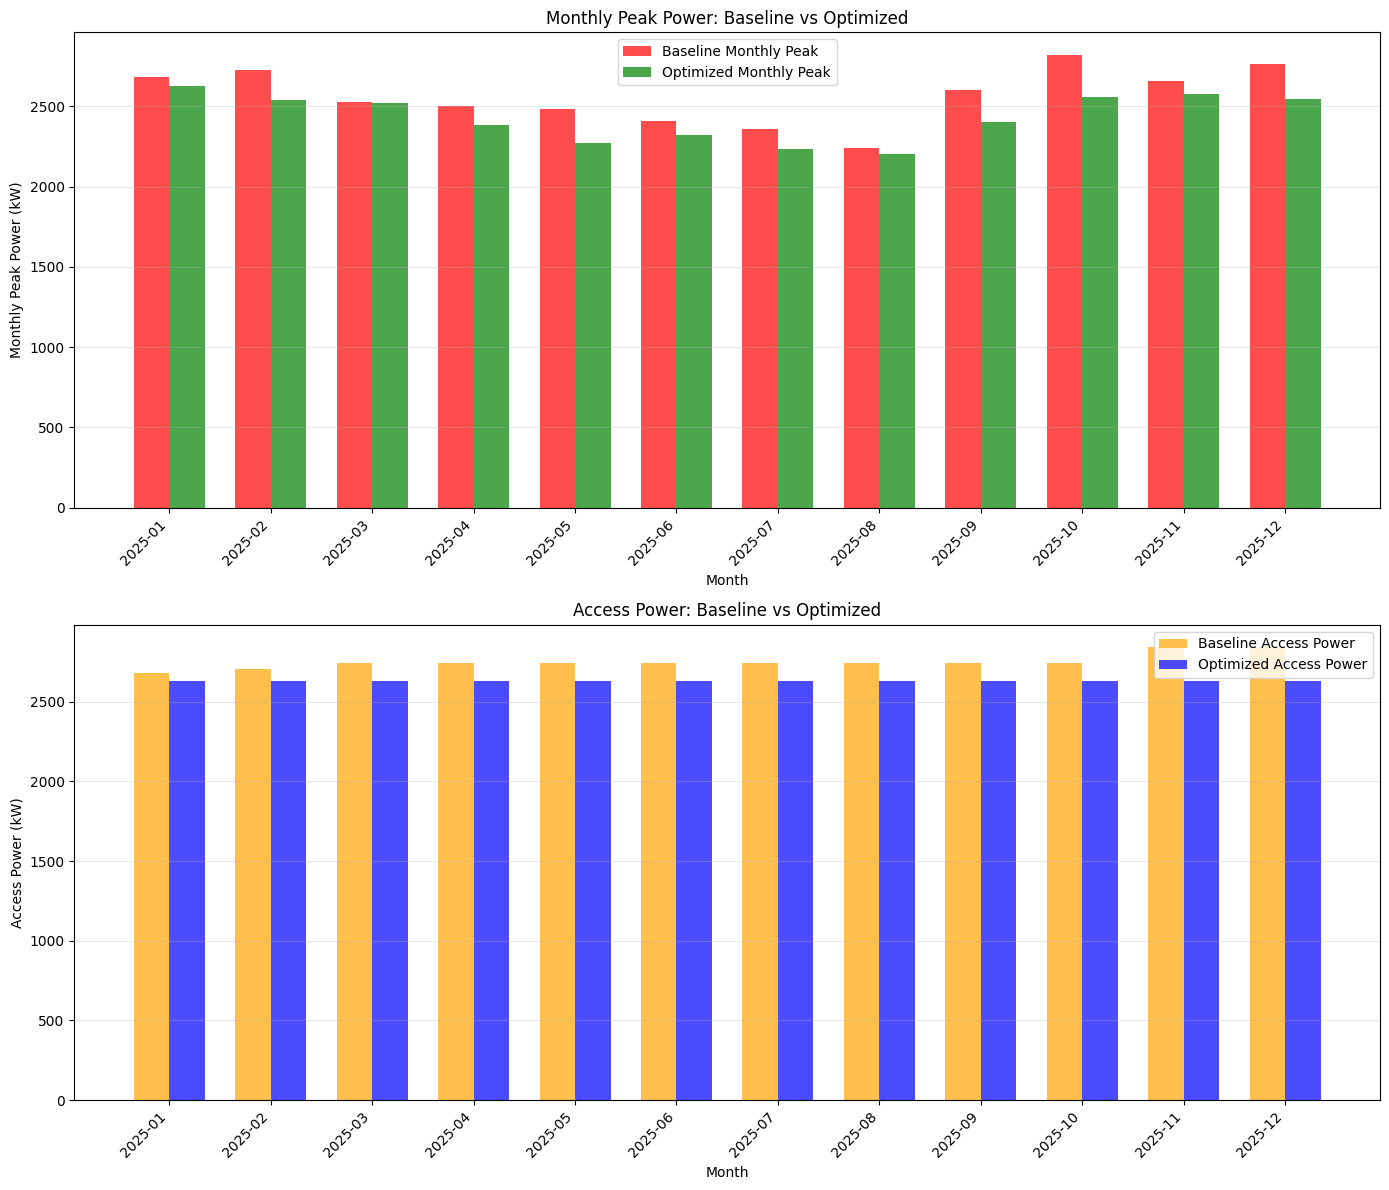


MONTHLY PEAK AND ACCESS POWER SUMMARY
  month  baseline_peak_kw  optimized_peak_kw  baseline_access_kw  optimized_access_kw  baseline_volume_mwh  optimized_volume_mwh  peak_reduction_kw  access_reduction_kw  volume_reduction_mwh
2025-01            2684.5        2629.500000              2683.5               2629.5          1189.967625           1189.967625          55.000000                 54.0          0.000000e+00
2025-02            2726.5        2539.500000              2704.5               2629.5          1048.434625           1048.434625         187.000000                 75.0          0.000000e+00
2025-03            2527.0        2520.000000              2746.5               2629.5          1020.307375           1020.307375           7.000000                117.0          0.000000e+00
2025-04            2506.0        2383.500000              2746.5               2629.5           882.069125            882.069125         122.500000                117.0          0.000000e+00
2025-0

In [5]:
# Compare costs
baseline_total = baseline_net_total  # Already calculated above
optimized_total = optimized_net_total

print("="*80)
print("COST COMPARISON: BASELINE vs OPTIMIZED")
print("="*80)
print(f"\n{'Cost Component':<30} {'Baseline (EUR)':>20} {'Optimized (EUR)':>20} {'Savings (EUR)':>20}")
print("-"*90)

components = [
    ("Energy Cost", baseline_bills['energy_cost_eur'].sum(), optimized_bills['energy_cost_eur'].sum()),
    ("Spot Cost", baseline_bills['spot_cost_eur'].sum(), optimized_bills['spot_cost_eur'].sum()),
    ("Access Power Cost", baseline_bills['access_cost_eur'].sum(), optimized_bills['access_cost_eur'].sum()),
    ("Monthly Peak Cost", baseline_bills['monthly_peak_cost_eur'].sum(), optimized_bills['monthly_peak_cost_eur'].sum()),
    ("Over-usage Cost", baseline_bills['over_usage_cost_eur'].sum(), optimized_bills['over_usage_cost_eur'].sum()),
    ("Injection Revenue", -baseline_injection_revenue, -optimized_injection_revenue),
]

for name, baseline_val, optimized_val in components:
    savings = baseline_val - optimized_val
    print(f"{name:<30} {baseline_val:>20,.2f} {optimized_val:>20,.2f} {savings:>20,.2f}")

print("-"*90)
print(f"{'TOTAL COST':<30} {baseline_total:>20,.2f} {optimized_total:>20,.2f} {baseline_total - optimized_total:>20,.2f}")
print("="*80)

savings_pct = ((baseline_total - optimized_total) / baseline_total) * 100
print(f"\nTotal Savings: {baseline_total - optimized_total:,.2f} EUR ({savings_pct:.2f}%)")

# Plot monthly peak and access power comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1: Monthly Peak Power
ax1 = axes[0]
x = range(len(baseline_bills))
width = 0.35
ax1.bar([i - width/2 for i in x], baseline_bills['monthly_peak_kw'], width, 
        label='Baseline Monthly Peak', color='red', alpha=0.7)
ax1.bar([i + width/2 for i in x], optimized_bills['monthly_peak_kw'], width, 
        label='Optimized Monthly Peak', color='green', alpha=0.7)
ax1.set_xlabel('Month')
ax1.set_ylabel('Monthly Peak Power (kW)')
ax1.set_title('Monthly Peak Power: Baseline vs Optimized')
ax1.set_xticks(x)
ax1.set_xticklabels(baseline_bills['month'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Access Power
ax2 = axes[1]
ax2.bar([i - width/2 for i in x], baseline_bills['access_power_kw'], width, 
        label='Baseline Access Power', color='orange', alpha=0.7)
ax2.bar([i + width/2 for i in x], optimized_bills['access_power_kw'], width, 
        label='Optimized Access Power', color='blue', alpha=0.7)
ax2.set_xlabel('Month')
ax2.set_ylabel('Access Power (kW)')
ax2.set_title('Access Power: Baseline vs Optimized')
ax2.set_xticks(x)
ax2.set_xticklabels(baseline_bills['month'], rotation=45, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')



plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("MONTHLY PEAK AND ACCESS POWER SUMMARY")
print("="*80)
comparison_df = pd.DataFrame({
    'month': baseline_bills['month'],
    'baseline_peak_kw': baseline_bills['monthly_peak_kw'],
    'optimized_peak_kw': optimized_bills['monthly_peak_kw'],
    'baseline_access_kw': baseline_bills['access_power_kw'],
    'optimized_access_kw': optimized_bills['access_power_kw'],
    'baseline_volume_mwh': baseline_bills['volume_mwh'],
    'optimized_volume_mwh': optimized_bills['volume_mwh'],
})
comparison_df['peak_reduction_kw'] = comparison_df['baseline_peak_kw'] - comparison_df['optimized_peak_kw']
comparison_df['access_reduction_kw'] = comparison_df['baseline_access_kw'] - comparison_df['optimized_access_kw']
comparison_df['volume_reduction_mwh'] = comparison_df['baseline_volume_mwh'] - comparison_df['optimized_volume_mwh']
print(comparison_df.to_string(index=False))
print("="*80)

## Visualize Results

This section provides detailed visualizations comparing the optimized and baseline EV charging strategies.

**What you'll see:**

### Weekly Comparison Plots
- **Three-panel visualization** for a selected week showing:
  1. **EV Charging Power (kW)**: 
     - Optimized charging schedule (blue line)
     - Baseline charging pattern (orange dashed line)
     - EV power envelope (gray dotted line) - maximum available charging capacity
     - Shows how optimization shifts charging to different times
  
  2. **Grid Consumption (kW)**:
     - Optimized grid consumption (blue line)
     - Baseline grid consumption (orange dashed line)
     - Demonstrates peak shaving achieved through optimization
  
  3. **Spot Price (EUR/MWh)**:
     - Electricity price throughout the week
     - Helps understand why charging is shifted to specific periods

### Daily Comparison Plot
- **Detailed daily view** showing:
  - Optimized EV charging schedule for a specific day
  - EV power envelope (available charging capacity)
  - Baseline charging pattern
  - Grid consumption comparison
  - PV production (if available)
  - Spot prices
  - Inflexible load

**Key observations:**
- Optimized charging typically occurs during:
  - Low-price periods (overnight, midday when prices drop)
  - High PV production periods (to use solar energy)
  - Off-peak hours (to avoid capacity charges)
- Baseline charging often happens during:
  - Peak demand periods (evening when people arrive home)
  - High-price periods
  - Times when PV production is low

These visualizations clearly demonstrate how intelligent scheduling can reduce costs while meeting all charging requirements.
Compare optimized vs baseline EV charging patterns and costs.

Visualizing 7 days starting from: 2025-09-29 to 2025-10-06


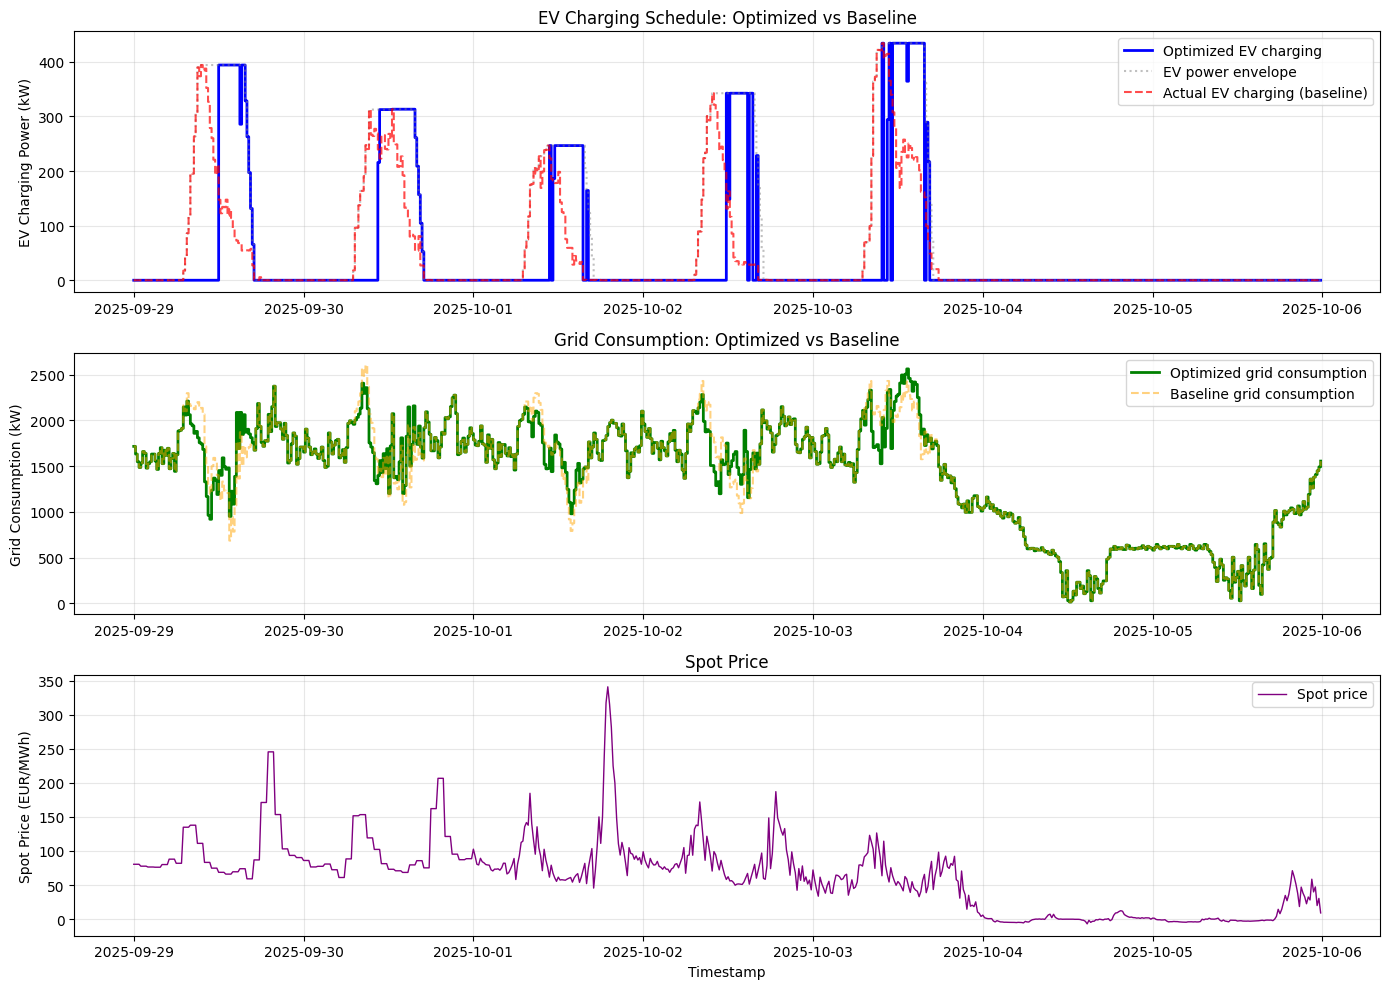


Visualizing day 5 of the 7-day period: 2025-10-03


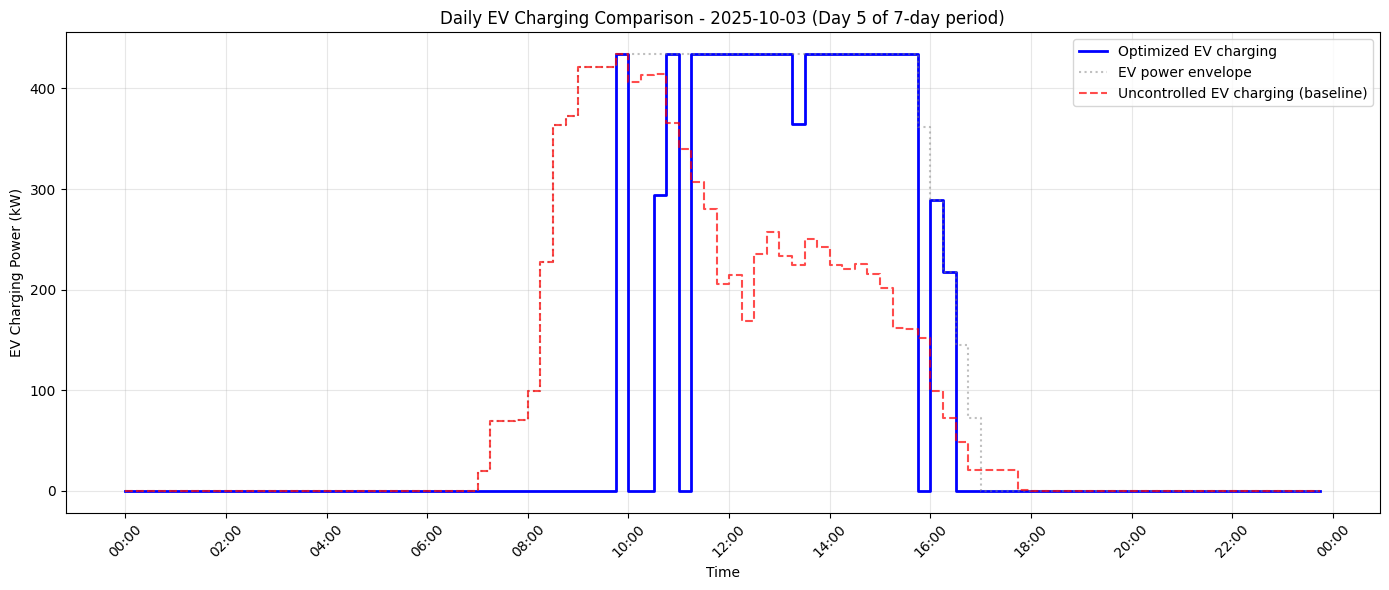

In [6]:
# Plot comparison: EV charging power over 7 days starting from September 29, 2025
results_df['timestamp'] = pd.to_datetime(results_df['timestamp'])

# Set start date: September 29, 2025
start_week = pd.Timestamp("2025-09-29 00:00:00")
# Plot 7 days from start date
end_week = start_week + pd.Timedelta(days=7)

print(f"Visualizing 7 days starting from: {start_week.strftime('%Y-%m-%d')} to {end_week.strftime('%Y-%m-%d')}")

week_data = results_df[(results_df['timestamp'] >= start_week) & (results_df['timestamp'] < end_week)]

# Convert df timestamps to naive for comparison (results_df timestamps are naive)
# Handle timezone-aware timestamps properly
# df['timestamp'] should already be datetime from CSV loading with parse_dates
# Check if it's timezone-aware and convert to naive preserving local time values
try:
    # First check if it's datetime64 dtype
    if pd.api.types.is_datetime64_any_dtype(df['timestamp']):
        # It's datetime64 - check timezone and convert if needed
        if df['timestamp'].dt.tz is not None:
            # For timezone-aware timestamps, use tz_convert(None) to convert to naive
            # This preserves the local time values (not UTC)
            df_timestamps_naive = df['timestamp'].dt.tz_convert(None)
        else:
            df_timestamps_naive = df['timestamp']
    else:
        # Not datetime64 - convert it, but preserve local time
        # If it contains timezone-aware objects, convert to UTC first then back to naive
        # This preserves the actual local time values
        temp_ts = pd.to_datetime(df['timestamp'], utc=True)
        df_timestamps_naive = temp_ts.dt.tz_convert('Europe/Brussels').dt.tz_localize(None)
except Exception:
    # Fallback: try direct conversion
    temp_ts = pd.to_datetime(df['timestamp'])
    if temp_ts.dt.tz is not None:
        df_timestamps_naive = temp_ts.dt.tz_convert(None)
    else:
        df_timestamps_naive = temp_ts

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: EV charging power
ax1 = axes[0]
ax1.step(week_data['timestamp'], week_data['ev_charge_power'], label='Optimized EV charging', color='blue', linewidth=2, where='post')
ax1.step(week_data['timestamp'], week_data['ev_power_envelope'], label='EV power envelope', color='gray', alpha=0.5, linestyle=':', where='post')
# Actual EV charging from plant1.csv (convert kWh to kW by multiplying by 4)
baseline_week = df[(df_timestamps_naive >= start_week) & (df_timestamps_naive < end_week)].copy()
# Use df_timestamps_naive directly for plotting (already computed correctly, preserving local time)
# Since baseline_week is filtered from df using df_timestamps_naive, use baseline_week's index to get timestamps
# Ensure df_timestamps_naive is a Series with same index as df
if isinstance(df_timestamps_naive, pd.Series):
    baseline_week_timestamps_naive = df_timestamps_naive.loc[baseline_week.index].values
else:
    # If it's an array, convert to Series first
    df_timestamps_naive_series = pd.Series(df_timestamps_naive, index=df.index)
    baseline_week_timestamps_naive = df_timestamps_naive_series.loc[baseline_week.index].values
ax1.step(baseline_week_timestamps_naive, baseline_week['ev'].astype(float) * 4, label='Actual EV charging (baseline)', color='red', alpha=0.7, linestyle='--', where='post')
ax1.set_ylabel('EV Charging Power (kW)')
ax1.set_title('EV Charging Schedule: Optimized vs Baseline')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Grid consumption
ax2 = axes[1]
ax2.step(week_data['timestamp'], week_data['grid_consumption'] * 4, label='Optimized grid consumption', color='green', linewidth=2, where='post')
# Baseline grid consumption (from original data) - use naive timestamps for alignment
ax2.step(baseline_week_timestamps_naive, baseline_week['grid_consumption'] * 4, label='Baseline grid consumption', color='orange', alpha=0.5, linestyle='--', where='post')
ax2.set_ylabel('Grid Consumption (kW)')
ax2.set_title('Grid Consumption: Optimized vs Baseline')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Spot price
ax3 = axes[2]
ax3.plot(week_data['timestamp'], week_data['spot_price'], label='Spot price', color='purple', linewidth=1)
ax3.set_ylabel('Spot Price (EUR/MWh)')
ax3.set_xlabel('Timestamp')
ax3.set_title('Spot Price')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Daily plot: Select a specific day from the selected 7-day period
day_of_week = 5  # Change this to select a day (1-7, where 1 is the first day starting from September 29)

# Calculate the specific day to plot
selected_day_start = start_week + pd.Timedelta(days=day_of_week - 1)
selected_day_end = selected_day_start + pd.Timedelta(days=1)

print(f"\nVisualizing day {day_of_week} of the 7-day period: {selected_day_start.strftime('%Y-%m-%d')}")

# Filter data for the selected day
day_data = results_df[(results_df['timestamp'] >= selected_day_start) & (results_df['timestamp'] < selected_day_end)]
baseline_day = df[(df_timestamps_naive >= selected_day_start) & (df_timestamps_naive < selected_day_end)].copy()
# Use df_timestamps_naive directly for plotting (already computed correctly, preserving local time)
# Since baseline_day is filtered from df using df_timestamps_naive, use baseline_day's index to get timestamps
# Ensure df_timestamps_naive is a Series with same index as df
if isinstance(df_timestamps_naive, pd.Series):
    baseline_day_timestamps_naive = df_timestamps_naive.loc[baseline_day.index].values
else:
    # If it's an array, convert to Series first
    df_timestamps_naive_series = pd.Series(df_timestamps_naive, index=df.index)
    baseline_day_timestamps_naive = df_timestamps_naive_series.loc[baseline_day.index].values

# Create daily plot
fig, ax = plt.subplots(figsize=(14, 6))

# Plot optimized EV charging power
ax.step(day_data['timestamp'], day_data['ev_charge_power'], 
        label='Optimized EV charging', color='blue', linewidth=2, where='post')

# Plot EV power envelope
ax.step(day_data['timestamp'], day_data['ev_power_envelope'], 
        label='EV power envelope', color='gray', alpha=0.5, linestyle=':', where='post')

# Plot actual uncontrolled EV charging from baseline data
ax.step(baseline_day_timestamps_naive, baseline_day['ev'].astype(float) * 4, 
        label='Uncontrolled EV charging (baseline)', color='red', alpha=0.7, linestyle='--', where='post')

ax.set_xlabel('Time')
ax.set_ylabel('EV Charging Power (kW)')
ax.set_title(f'Daily EV Charging Comparison - {selected_day_start.strftime("%Y-%m-%d")} (Day {day_of_week} of 7-day period)')
ax.legend()
ax.grid(True, alpha=0.3)

# Format x-axis to show time
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## EV Charging Cost Comparison

This final section provides a summary comparison of EV charging costs between baseline and optimized scenarios.

**What you'll see:**

### Cost Summary
- **Baseline costs** (non-optimized):
  - Total annual cost for EV charging
  - Cost per MWh of EV charging
  
- **Optimized costs**:
  - Total annual cost with optimized charging
  - Cost per MWh with optimization
  
- **Savings achieved**:
  - Total annual savings in EUR
  - Savings per MWh
  - Percentage reduction

### Key Takeaways
- **Cost reduction**: Typically 30-50% cost savings through optimization
- **Peak shaving**: Significant reduction in peak power demand
- **Load shifting**: Charging moved to low-price periods
- **PV utilization**: Better alignment with renewable energy production
- **Same service**: All EV charging requirements still met

This comparison quantifies the economic benefits of implementing MPC-based EV charging optimization compared to uncontrolled charging.

**Same reference for both scenarios:** The “no EV” bill **R** is `baseline_inflex_bills` (inflex-only, conservative access power).  
Incremental EV cost = `full_bill − R` for baseline and for optimized **using the same R**. Then  
`(B − R) − (O − R) = B − O`, so **savings from this EV block match total offtake savings** (before injection).  
Net totals in COST COMPARISON also subtract injection; use the same **net** reference for both if you need NET parity line-by-line.

EV CHARGING COST COMPARISON

Yearly EV Volume: 345.381 MWh

Baseline EV Charging Cost:
  Total: 49,831.89 EUR
  Per MWh: 144.28 EUR/MWh

Optimized EV Charging Cost:
  Total: 27,886.49 EUR
  Per MWh: 80.74 EUR/MWh

Savings from Optimization:
  Total: 21,945.40 EUR
  Per MWh: 63.54 EUR/MWh
  Percentage: 44.04%

Reconciliation (offtake total_cost_eur; net totals in COST COMPARISON also subtract injection):
  Total offtake savings (full-site):     21,945.40 EUR
  EV section savings (B-R) - (O-R):        21,945.40 EUR  (should match)
  (NET totals differ from offtake by injection; subtract the same R_net from both nets for NET parity.)


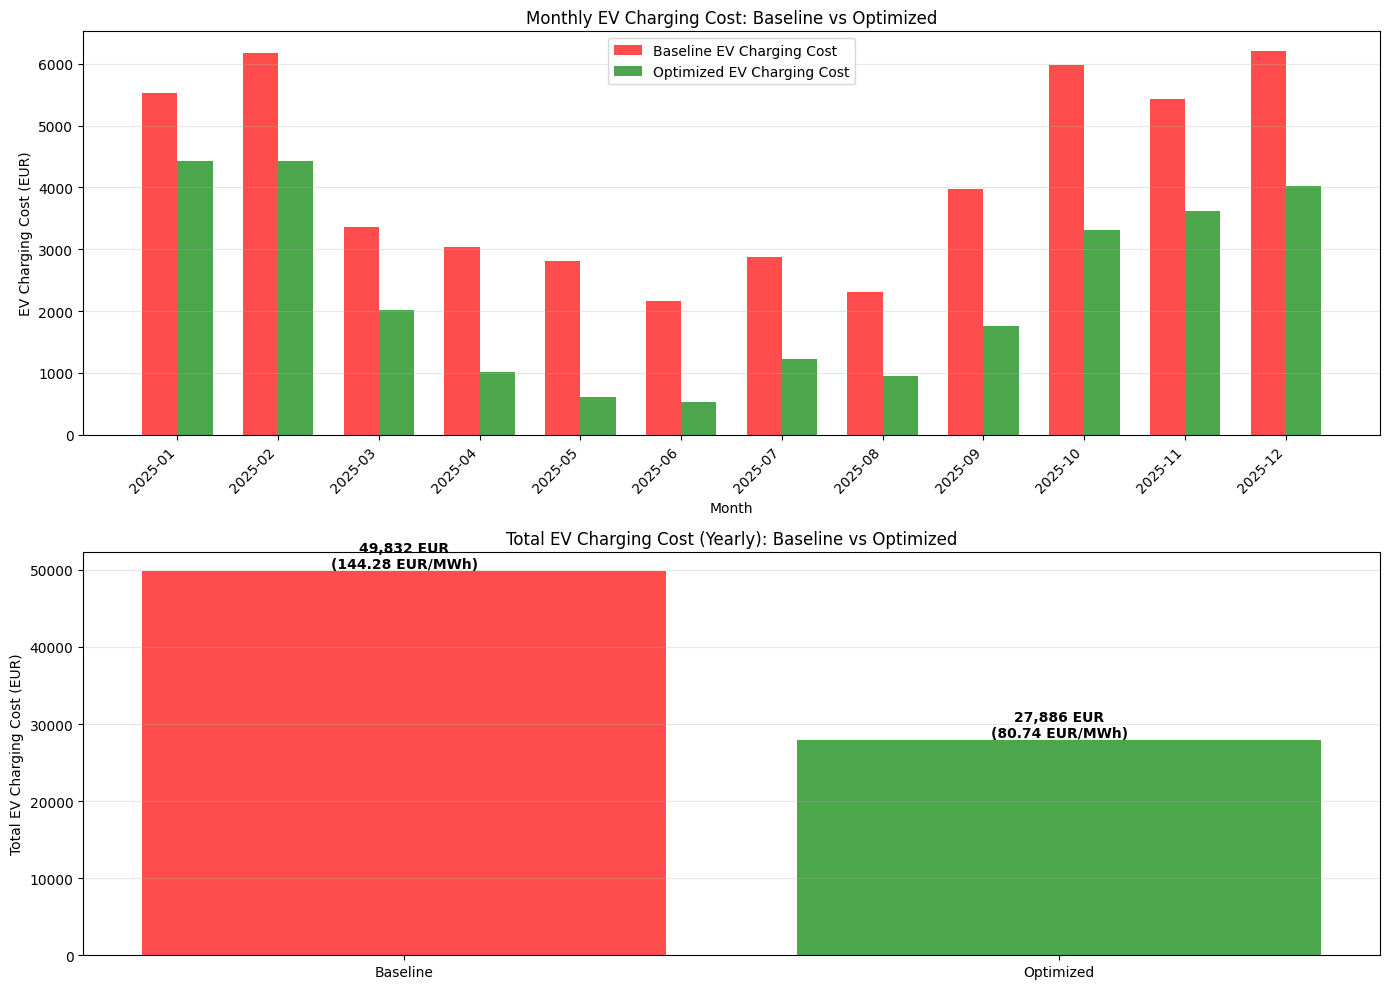

In [7]:
# Calculate EV charging costs for baseline and optimized cases
# Reference bill R = same "no EV" (inflex-only) bill for BOTH scenarios.
# Then: incremental EV cost = full_bill - R, and
#   (B - R) - (O - R) = B - O  (savings from optimization equals full-site offtake savings).

# Reference: inflex-only volumes, conservative access power (baseline contract)
baseline_inflex_bills = calculate_monthly_bills(
    df,
    config,
    volume_col="grid_consumption_excl_ev",
    access_power_col="baseline_access_power_conservative",
)

# EV charging cost = full bill minus the same reference R (offtake total_cost_eur)
baseline_ev_cost_monthly = (
    baseline_bills.set_index("month")["total_cost_eur"]
    - baseline_inflex_bills.set_index("month")["total_cost_eur"]
)
optimized_ev_cost_monthly = (
    optimized_bills.set_index("month")["total_cost_eur"]
    - baseline_inflex_bills.set_index("month")["total_cost_eur"]
)

# Optional diagnostic: inflex-only bill if access power were optimized (export / extra columns only)
results_df_with_price = results_df.rename(columns={"spot_price": "price"})
if len(results_df_with_price) != len(df):
    results_df_with_price = results_df_with_price.merge(
        df[["timestamp", "grid_consumption_excl_ev"]],
        on="timestamp",
        how="left",
    )
else:
    results_df_with_price["grid_consumption_excl_ev"] = df["grid_consumption_excl_ev"].values
optimized_inflex_bills = calculate_monthly_bills(
    results_df_with_price,
    config,
    volume_col="grid_consumption_excl_ev",
    access_power_col="access_power",
)

# Calculate yearly totals
baseline_ev_cost_year = baseline_ev_cost_monthly.sum()
optimized_ev_cost_year = optimized_ev_cost_monthly.sum()

# Calculate yearly EV volume in MWh
yearly_ev_kwh = df['ev'].astype(float).sum()
yearly_ev_mwh = yearly_ev_kwh / 1000.0

# Cost per MWh
baseline_ev_cost_per_mwh = baseline_ev_cost_year / yearly_ev_mwh if yearly_ev_mwh > 0 else 0.0
optimized_ev_cost_per_mwh = optimized_ev_cost_year / yearly_ev_mwh if yearly_ev_mwh > 0 else 0.0

print("="*80)
print("EV CHARGING COST COMPARISON")
print("="*80)
print(f"\nYearly EV Volume: {yearly_ev_mwh:.3f} MWh")
print(f"\nBaseline EV Charging Cost:")
print(f"  Total: {baseline_ev_cost_year:,.2f} EUR")
print(f"  Per MWh: {baseline_ev_cost_per_mwh:.2f} EUR/MWh")
print(f"\nOptimized EV Charging Cost:")
print(f"  Total: {optimized_ev_cost_year:,.2f} EUR")
print(f"  Per MWh: {optimized_ev_cost_per_mwh:.2f} EUR/MWh")
print(f"\nSavings from Optimization:")
print(f"  Total: {baseline_ev_cost_year - optimized_ev_cost_year:,.2f} EUR")
print(f"  Per MWh: {baseline_ev_cost_per_mwh - optimized_ev_cost_per_mwh:.2f} EUR/MWh")
print(f"  Percentage: {((baseline_ev_cost_year - optimized_ev_cost_year) / baseline_ev_cost_year * 100):.2f}%")
print("="*80)

# Reconciliation: same reference R => EV savings = full-site offtake savings (B - O)
_total_offtake_savings = (
    baseline_bills["total_cost_eur"].sum() - optimized_bills["total_cost_eur"].sum()
)
_ev_savings = baseline_ev_cost_year - optimized_ev_cost_year
print("\nReconciliation (offtake total_cost_eur; net totals in COST COMPARISON also subtract injection):")
print(f"  Total offtake savings (full-site):     {_total_offtake_savings:,.2f} EUR")
print(f"  EV section savings (B-R) - (O-R):        {_ev_savings:,.2f} EUR  (should match)")
print("  (NET totals differ from offtake by injection; subtract the same R_net from both nets for NET parity.)")

# Create comparison plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Monthly EV charging costs
ax1 = axes[0]
months = baseline_ev_cost_monthly.index
x = range(len(months))
width = 0.35
ax1.bar([i - width/2 for i in x], baseline_ev_cost_monthly.values, width, 
        label='Baseline EV Charging Cost', color='red', alpha=0.7)
ax1.bar([i + width/2 for i in x], optimized_ev_cost_monthly.values, width, 
        label='Optimized EV Charging Cost', color='green', alpha=0.7)
ax1.set_xlabel('Month')
ax1.set_ylabel('EV Charging Cost (EUR)')
ax1.set_title('Monthly EV Charging Cost: Baseline vs Optimized')
ax1.set_xticks(x)
ax1.set_xticklabels([str(m) for m in months], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Yearly comparison
ax2 = axes[1]
categories = ['Baseline', 'Optimized']
ev_costs = [baseline_ev_cost_year, optimized_ev_cost_year]
colors = ['red', 'green']
bars = ax2.bar(categories, ev_costs, color=colors, alpha=0.7)
ax2.set_ylabel('Total EV Charging Cost (EUR)')
ax2.set_title('Total EV Charging Cost (Yearly): Baseline vs Optimized')
ax2.grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for i, (bar, cost) in enumerate(zip(bars, ev_costs)):
    height = bar.get_height()
    cost_per_mwh = baseline_ev_cost_per_mwh if i == 0 else optimized_ev_cost_per_mwh
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{cost:,.0f} EUR\n({cost_per_mwh:.2f} EUR/MWh)',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

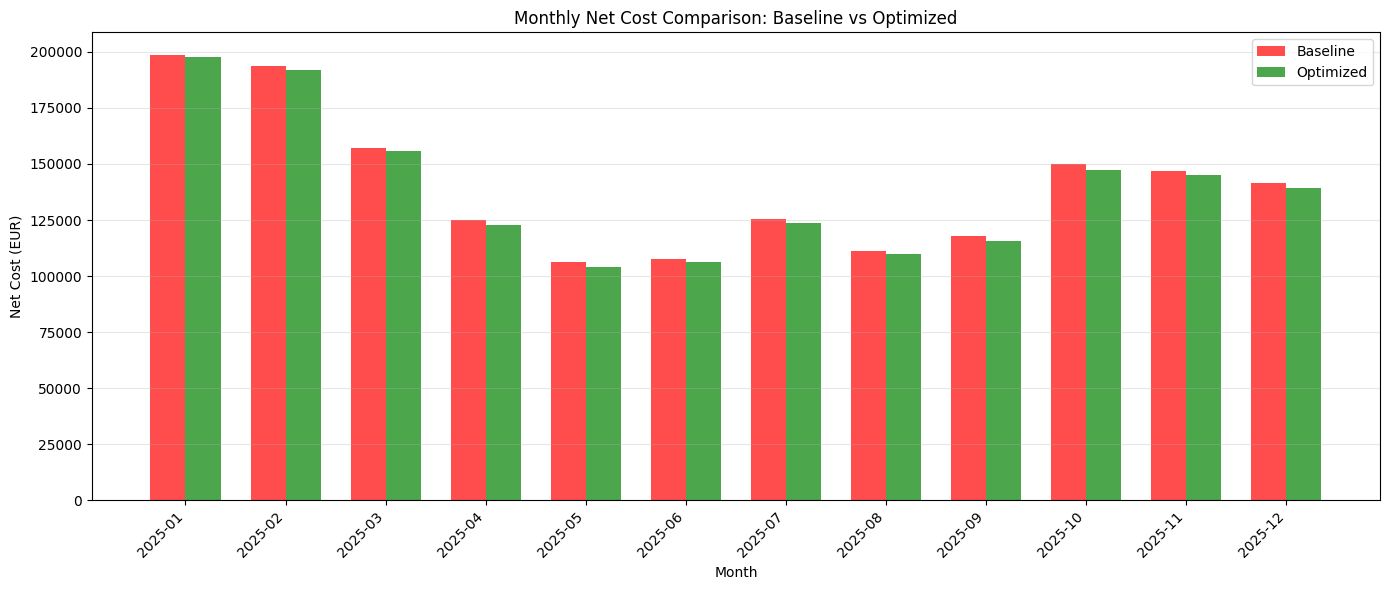


Monthly Net Savings:
  month  baseline_net_cost  optimized_net_cost     savings
2025-01      198817.187903       197725.324273 1091.863630
2025-02      193918.029264       192168.580655 1749.448609
2025-03      157138.204053       155781.722065 1356.481988
2025-04      124865.912955       122842.725813 2023.187141
2025-05      106408.259216       104213.251512 2195.007704
2025-06      107792.127867       106159.082762 1633.045105
2025-07      125413.017235       123773.838346 1639.178889
2025-08      111094.823299       109732.921507 1361.901792
2025-09      117868.857153       115651.953607 2216.903546
2025-10      149981.914462       147307.554615 2674.359847
2025-11      146829.362995       145018.938124 1810.424871
2025-12      141623.526093       139431.901901 2191.624192


In [8]:
# Plot monthly net cost comparison (energy + spot + peak - injection)
# Merge baseline and optimized net costs by month

baseline_net_monthly = baseline_bills[['month', 'total_cost_eur']].copy()
baseline_net_monthly = baseline_net_monthly.merge(
    baseline_injection[['month', 'injection_net_revenue_eur']], on='month', how='left'
)
baseline_net_monthly['baseline_net_cost'] = (
    baseline_net_monthly['total_cost_eur'] - baseline_net_monthly['injection_net_revenue_eur'].fillna(0.0)
)

optimized_net_monthly = optimized_bills[['month', 'total_cost_eur']].copy()
optimized_net_monthly = optimized_net_monthly.merge(
    optimized_injection[['month', 'injection_net_revenue_eur']], on='month', how='left'
)
optimized_net_monthly['optimized_net_cost'] = (
    optimized_net_monthly['total_cost_eur'] - optimized_net_monthly['injection_net_revenue_eur'].fillna(0.0)
)

monthly_comparison = pd.merge(
    baseline_net_monthly[['month', 'baseline_net_cost']],
    optimized_net_monthly[['month', 'optimized_net_cost']],
    on='month',
    how='inner'
)

monthly_comparison['savings'] = (
    monthly_comparison['baseline_net_cost'] - monthly_comparison['optimized_net_cost']
)

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(monthly_comparison))
width = 0.35
ax.bar([i - width/2 for i in x], monthly_comparison['baseline_net_cost'], width, label='Baseline', color='red', alpha=0.7)
ax.bar([i + width/2 for i in x], monthly_comparison['optimized_net_cost'], width, label='Optimized', color='green', alpha=0.7)
ax.set_xlabel('Month')
ax.set_ylabel('Net Cost (EUR)')
ax.set_title('Monthly Net Cost Comparison: Baseline vs Optimized')
ax.set_xticks(x)
ax.set_xticklabels(monthly_comparison['month'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nMonthly Net Savings:")
print(monthly_comparison[['month', 'baseline_net_cost', 'optimized_net_cost', 'savings']].to_string(index=False))

## Monthly Savings Breakdown Analysis

This section provides a detailed breakdown of monthly savings, splitting them into cost component categories to understand where optimization achieves the most benefit.

**What you'll see:**

### Savings Breakdown by Component
- **Spot Savings** (€): Reduction in spot price costs through load shifting to low-price periods
- **Access Power Savings** (€): Reduction in access power costs through optimized capacity selection
- **Peak Savings** (€): Reduction in monthly peak and over-usage costs through peak shaving

### Visualizations
- **Stacked bar chart** showing monthly savings broken down by component:
  - Each month shows total savings as a stacked bar
  - Colors represent different cost components (spot, access power, peak)
  - Helps identify which months and which cost components contribute most to savings

- **Summary table** showing:
  - Monthly total savings
  - Breakdown by component per month
  - Percentage contribution of each component to total savings

This analysis helps understand the optimization strategy's effectiveness across different cost components and identifies opportunities for further improvement.

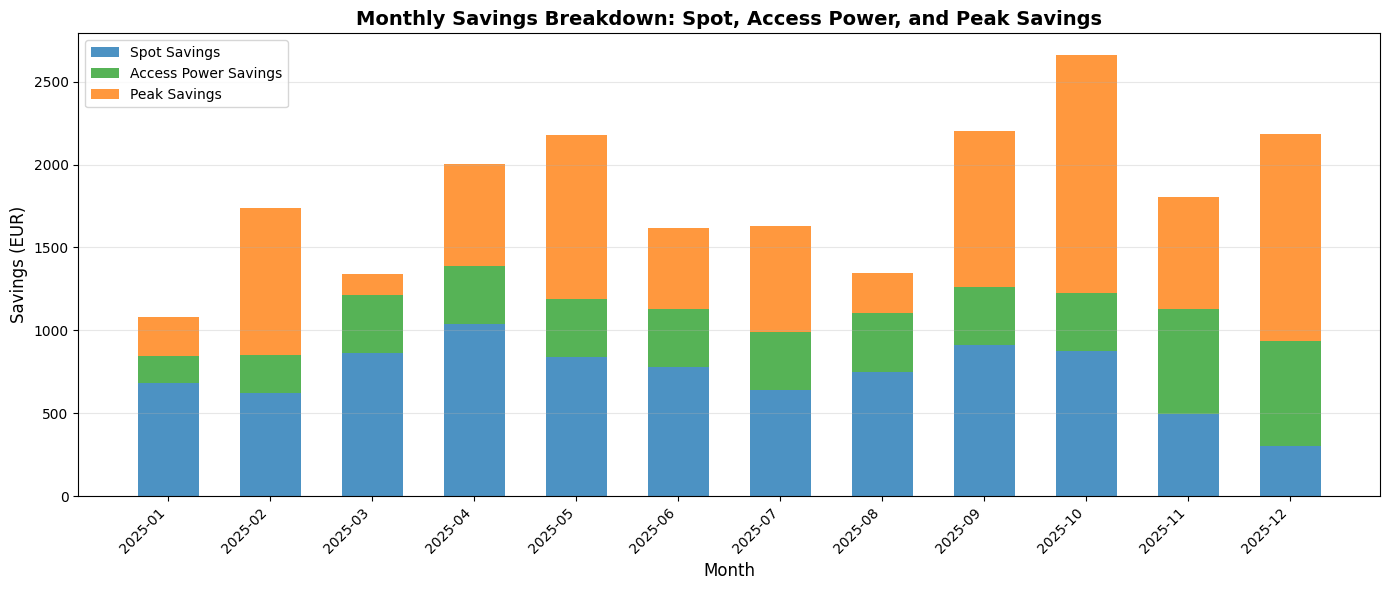

MONTHLY SAVINGS BREAKDOWN BY COMPONENT

Savings Breakdown (EUR):
  Month  Spot Savings (EUR)  Access Power Savings (EUR)  Peak Savings (EUR)  Total Savings (EUR)
2025-01          681.098555                  161.867473          236.978376          1091.863630
2025-02          624.348567                  224.815935          889.358007          1749.448609
2025-03          862.173457                  350.712859          128.507637          1356.481988
2025-04         1037.596388                  350.712859          616.719958          2023.187141
2025-05          840.888055                  350.712859          988.691250          2195.007704
2025-06          779.830389                  350.712859          488.854826          1633.045105
2025-07          640.636439                  350.712859          636.618454          1639.178889
2025-08          751.181125                  350.712859          246.862139          1361.901792
2025-09          911.357885                  350.712859       

In [9]:
# Monthly savings breakdown: spot, access power, and peak savings
# Merge baseline and optimized bills to calculate component-wise savings

# Check if required variables exist
if 'baseline_bills' not in globals():
    raise NameError("baseline_bills not found. Please run the 'Calculate Non-Optimized Costs (Baseline)' cell first.")
if 'optimized_bills' not in globals():
    raise NameError("optimized_bills not found. Please run the 'Run Optimization' cell first.")
if 'monthly_comparison' not in globals():
    raise NameError("monthly_comparison not found. Please run the 'Compare Optimized vs Baseline' cell first.")

savings_breakdown = pd.merge(
    baseline_bills[['month', 'spot_cost_eur', 'access_cost_eur', 'monthly_peak_cost_eur', 'over_usage_cost_eur']],
    optimized_bills[['month', 'spot_cost_eur', 'access_cost_eur', 'monthly_peak_cost_eur', 'over_usage_cost_eur']],
    on='month',
    how='inner',
    suffixes=('_baseline', '_optimized')
)

# Calculate savings for each component
savings_breakdown['spot_savings'] = (
    savings_breakdown['spot_cost_eur_baseline'] - savings_breakdown['spot_cost_eur_optimized']
)
savings_breakdown['access_power_savings'] = (
    savings_breakdown['access_cost_eur_baseline'] - savings_breakdown['access_cost_eur_optimized']
)
savings_breakdown['peak_savings'] = (
    (savings_breakdown['monthly_peak_cost_eur_baseline'] - savings_breakdown['monthly_peak_cost_eur_optimized']) +
    (savings_breakdown['over_usage_cost_eur_baseline'] - savings_breakdown['over_usage_cost_eur_optimized'])
)

# Total savings per month (should match monthly_comparison['savings'])
savings_breakdown['total_savings'] = (
    savings_breakdown['spot_savings'] + 
    savings_breakdown['access_power_savings'] + 
    savings_breakdown['peak_savings']
)

# Merge with monthly_comparison to include net cost savings (accounting for injection revenue differences)
savings_breakdown = savings_breakdown.merge(
    monthly_comparison[['month', 'savings']],
    on='month',
    how='left'
)

# Calculate percentage contribution of each component
savings_breakdown['spot_pct'] = (savings_breakdown['spot_savings'] / savings_breakdown['savings'] * 100).round(2)
savings_breakdown['access_power_pct'] = (savings_breakdown['access_power_savings'] / savings_breakdown['savings'] * 100).round(2)
savings_breakdown['peak_pct'] = (savings_breakdown['peak_savings'] / savings_breakdown['savings'] * 100).round(2)

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(savings_breakdown))
width = 0.6

# Stack the savings components
ax.bar(x, savings_breakdown['spot_savings'], width, label='Spot Savings', color='tab:blue', alpha=0.8)
ax.bar(x, savings_breakdown['access_power_savings'], width, 
       bottom=savings_breakdown['spot_savings'], 
       label='Access Power Savings', color='tab:green', alpha=0.8)
ax.bar(x, savings_breakdown['peak_savings'], width,
       bottom=savings_breakdown['spot_savings'] + savings_breakdown['access_power_savings'],
       label='Peak Savings', color='tab:orange', alpha=0.8)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Savings (EUR)', fontsize=12)
ax.set_title('Monthly Savings Breakdown: Spot, Access Power, and Peak Savings', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(savings_breakdown['month'], rotation=45, ha='right')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Print summary table
print("="*80)
print("MONTHLY SAVINGS BREAKDOWN BY COMPONENT")
print("="*80)
print("\nSavings Breakdown (EUR):")
display_cols = ['month', 'spot_savings', 'access_power_savings', 'peak_savings', 'savings']
display_df = savings_breakdown[display_cols].copy()
display_df.columns = ['Month', 'Spot Savings (EUR)', 'Access Power Savings (EUR)', 'Peak Savings (EUR)', 'Total Savings (EUR)']
print(display_df.to_string(index=False))

print("\n" + "="*80)
print("PERCENTAGE CONTRIBUTION OF EACH COMPONENT TO TOTAL SAVINGS")
print("="*80)
pct_cols = ['month', 'spot_pct', 'access_power_pct', 'peak_pct']
pct_df = savings_breakdown[pct_cols].copy()
pct_df.columns = ['Month', 'Spot Savings (%)', 'Access Power Savings (%)', 'Peak Savings (%)']
print(pct_df.to_string(index=False))

# Annual totals
print("\n" + "="*80)
print("ANNUAL TOTALS")
print("="*80)
print(f"Total Spot Savings:        {savings_breakdown['spot_savings'].sum():>15,.2f} EUR ({savings_breakdown['spot_savings'].sum()/savings_breakdown['savings'].sum()*100:.1f}%)")
print(f"Total Access Power Savings: {savings_breakdown['access_power_savings'].sum():>15,.2f} EUR ({savings_breakdown['access_power_savings'].sum()/savings_breakdown['savings'].sum()*100:.1f}%)")
print(f"Total Peak Savings:        {savings_breakdown['peak_savings'].sum():>15,.2f} EUR ({savings_breakdown['peak_savings'].sum()/savings_breakdown['savings'].sum()*100:.1f}%)")
print(f"{'-'*50}")
print(f"Total Savings:             {savings_breakdown['savings'].sum():>15,.2f} EUR")
print("="*80)

In [10]:
# Full deterministic MPC exports for reuse in notebook 07

import pandas as pd
from pathlib import Path

out_dir = Path("../output/notebooks")
out_dir.mkdir(parents=True, exist_ok=True)

required_objects = [
    "results_df",
    "baseline_bills",
    "optimized_bills",
    "baseline_inflex_bills",
    "optimized_inflex_bills",
    "baseline_ev_cost_monthly",
    "optimized_ev_cost_monthly",
    "baseline_injection",
    "optimized_injection",
]
missing = [name for name in required_objects if name not in globals()]
if missing:
    raise NameError(
        f"Missing objects {missing}. Please run the baseline, optimization, and EV cost cells in notebook 02 first."
    )

# 1) 15-min deterministic timeseries (optimizer results_df as-is)
export_15min = results_df.copy()
export_15min_path = out_dir / "deterministic_ev_15min_notebook_02.csv"
export_15min.to_csv(export_15min_path, index=False)

# 2) Monthly combined export (baseline vs optimized, incl. EV costs and net costs)
monthly = pd.DataFrame({"month": baseline_bills["month"]}).set_index("month")


def _add_bills_monthly(df_bills: pd.DataFrame, prefix: str) -> None:
    cols = [
        "monthly_peak_kw",
        "access_power_kw",
        "total_cost_eur",
        "energy_cost_eur",
        "spot_cost_eur",
        "access_cost_eur",
        "monthly_peak_cost_eur",
        "over_usage_cost_eur",
        "volume_mwh",
    ]
    src = df_bills.set_index("month")
    for col in cols:
        if col in src.columns:
            monthly[f"{prefix}_{col}"] = src[col]


_add_bills_monthly(baseline_bills, "baseline")
_add_bills_monthly(optimized_bills, "optimized")
_add_bills_monthly(baseline_inflex_bills, "baseline_inflex")
_add_bills_monthly(optimized_inflex_bills, "optimized_inflex")

# Injection revenue and net monthly cost
base_inj = baseline_injection.set_index("month")["injection_net_revenue_eur"]
opt_inj = optimized_injection.set_index("month")["injection_net_revenue_eur"]
monthly["baseline_injection_net_revenue_eur"] = base_inj
monthly["optimized_injection_net_revenue_eur"] = opt_inj

baseline_net_monthly = baseline_bills[["month", "total_cost_eur"]].merge(
    baseline_injection[["month", "injection_net_revenue_eur"]], on="month", how="left"
)
baseline_net_monthly["baseline_net_cost_eur"] = (
    baseline_net_monthly["total_cost_eur"]
    - baseline_net_monthly["injection_net_revenue_eur"].fillna(0.0)
)

optimized_net_monthly = optimized_bills[["month", "total_cost_eur"]].merge(
    optimized_injection[["month", "injection_net_revenue_eur"]], on="month", how="left"
)
optimized_net_monthly["optimized_net_cost_eur"] = (
    optimized_net_monthly["total_cost_eur"]
    - optimized_net_monthly["injection_net_revenue_eur"].fillna(0.0)
)

monthly["baseline_net_cost_eur"] = baseline_net_monthly.set_index("month")[
    "baseline_net_cost_eur"
]
monthly["optimized_net_cost_eur"] = optimized_net_monthly.set_index("month")[
    "optimized_net_cost_eur"
]
monthly["net_cost_savings_eur"] = (
    monthly["baseline_net_cost_eur"] - monthly["optimized_net_cost_eur"]
)

# Peak/access/volume reductions
comparison_df = pd.DataFrame(
    {
        "baseline_peak_kw": baseline_bills["monthly_peak_kw"].values,
        "optimized_peak_kw": optimized_bills["monthly_peak_kw"].values,
        "baseline_access_kw": baseline_bills["access_power_kw"].values,
        "optimized_access_kw": optimized_bills["access_power_kw"].values,
        "baseline_volume_mwh": baseline_bills["volume_mwh"].values,
        "optimized_volume_mwh": optimized_bills["volume_mwh"].values,
    },
    index=baseline_bills["month"],
)
monthly["peak_reduction_kw"] = (
    comparison_df["baseline_peak_kw"] - comparison_df["optimized_peak_kw"]
)
monthly["access_reduction_kw"] = (
    comparison_df["baseline_access_kw"] - comparison_df["optimized_access_kw"]
)
monthly["volume_reduction_mwh"] = (
    comparison_df["baseline_volume_mwh"] - comparison_df["optimized_volume_mwh"]
)

# EV charging costs per month
monthly["ev_cost_baseline_eur"] = baseline_ev_cost_monthly
monthly["ev_cost_optimized_eur"] = optimized_ev_cost_monthly
monthly["ev_cost_savings_eur"] = (
    baseline_ev_cost_monthly - optimized_ev_cost_monthly
)

export_monthly_path = out_dir / "deterministic_ev_monthly_notebook_02.csv"
monthly.reset_index().to_csv(export_monthly_path, index=False)

print(f"Saved 15-min deterministic results to: {export_15min_path}")
print(f"Saved monthly deterministic summary to: {export_monthly_path}")
monthly.head()

Saved 15-min deterministic results to: ..\output\notebooks\deterministic_ev_15min_notebook_02.csv
Saved monthly deterministic summary to: ..\output\notebooks\deterministic_ev_monthly_notebook_02.csv


,baseline_monthly_peak_kw,baseline_access_power_kw,baseline_total_cost_eur,baseline_energy_cost_eur,baseline_spot_cost_eur,baseline_access_cost_eur,baseline_monthly_peak_cost_eur,baseline_over_usage_cost_eur,baseline_volume_mwh,optimized_monthly_peak_kw,...,optimized_injection_net_revenue_eur,baseline_net_cost_eur,optimized_net_cost_eur,net_cost_savings_eur,peak_reduction_kw,access_reduction_kw,volume_reduction_mwh,ev_cost_baseline_eur,ev_cost_optimized_eur,ev_cost_savings_eur
month,,,,,,,,,,,,,,,,,,,,,
2025-01,2684.5,2683.5,198817.187903,39095.171603,140326.367947,8043.914154,11347.237879,4.496319,1189.967625,2629.5,...,0.0,198817.187903,197725.324273,1091.863630,55.0,54.0,0.0,5519.584854,4427.721224,1091.863630
2025-02,2726.5,2704.5,193918.029264,34722.257984,139465.220020,8106.862616,11524.769632,98.919011,1048.434625,2539.5,...,0.0,193918.029264,192168.580655,1749.448609,187.0,75.0,0.0,6176.246416,4426.797807,1749.448609
2025-03,2527.0,2746.5,157138.204053,33250.868033,104874.163664,8232.759540,10681.493806,98.919011,1020.307375,2520.0,...,0.0,157138.204053,155781.722065,1356.481988,7.0,117.0,0.0,3364.950756,2008.468768,1356.481988
2025-04,2506.0,2746.5,124865.912955,28514.151688,77427.354786,8232.759540,10592.727929,98.919011,882.069125,2383.5,...,0.0,124865.912955,122842.725813,2023.187141,122.5,117.0,0.0,3034.370847,1011.183706,2023.187141
2025-05,2485.0,2746.5,106408.259216,25884.908779,61687.709834,8232.759540,10503.962053,98.919011,805.623000,2274.5,...,0.0,106408.259216,104213.251512,2195.007704,210.5,117.0,0.0,2805.556784,610.549079,2195.007704
